# Calibration of a line

The whole `rxmc` workflow on the smallest possible problem: declare a model
with parameters and priors, a dataset, and a comparison between them; compile
the problem; hand it to an external sampler; read the chain back by name; and
check the posterior predictive against the data.

Recipes: 1, 17

In [1]:
import corner
import emcee
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

import rxmc as rx

## Parameters and a model

A `Parameter` is a name with a prior (or finite bounds).  A `Model` is a
callable of the grid `x` and the parameter values, in order, with its
parameters listed.  Here the prior is deliberately at odds with the data we
are about to generate: it encodes what we think we know before looking.

In [2]:
m = rx.Parameter("m", prior=stats.norm(1.0, 1.0), latex="m")
b = rx.Parameter("b", prior=stats.norm(1.0, 1.0), latex="b")
line = rx.Model(lambda x, m, b: m * x + b, [m, b])
line

Model(params=(m, b))

## Data

Twenty points on a line with independent Gaussian noise of known size, which the
experiment reports honestly as `y_err`.

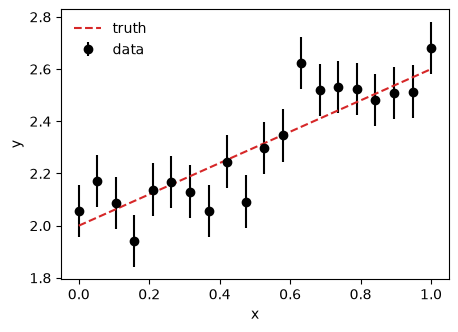

In [3]:
rng = np.random.default_rng(49)
truth = {"m": 0.6, "b": 2.0}
x = np.linspace(0.0, 1.0, 20)
y_true = truth["m"] * x + truth["b"]
sigma = 0.1
data = rx.Dataset(
    x, y_true + rng.normal(0.0, sigma, x.size), sigma * np.ones(x.size), label="toy"
)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.errorbar(data.x, data.y, data.y_err, fmt="o", color="k", label="data")
ax.plot(x, y_true, "--", color="C3", label="truth")
ax.set(xlabel="x", ylabel="y")
ax.legend(frameon=False)
plt.show()

## A comparison, a constraint and a problem

A `Comparison` binds the model to the dataset's grid.  A `Constraint` is one
likelihood over one or more comparisons; by default its covariance is the
diagonal of the reported errors.  `Problem` compiles everything: it assigns
every parameter a column, assembles the prior, and exposes the densities a
sampler needs.

In [4]:
comp = rx.Comparison(data, line)
problem = rx.Problem([rx.Constraint([comp])])
print(problem)
print("columns:", problem.names)

Problem(ndim=2, constraints=1)
columns: ['m', 'b']


### The prior predictive

Before touching the likelihood, draw parameters from the prior and push them
through the model.  This is what our prior says the data could look like.

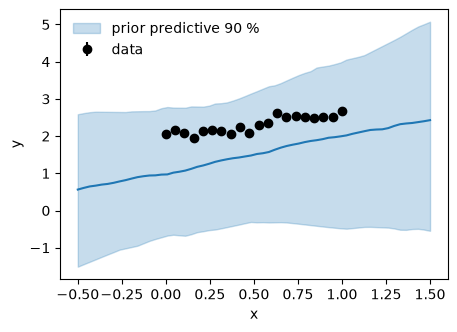

In [5]:
prior_draws = problem.sample_prior(200, rng=1)
x_fine = np.linspace(-0.5, 1.5, 60)
on_fine = line.bind(x_fine, {})  # the same model on a plotting grid
prior_curves = np.array(
    [on_fine(*s[problem.columns(line.params)]) for s in prior_draws]
)
lo, mid, hi = rx.predictive.predictive_band(prior_curves, levels=(5, 50, 95))

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.fill_between(x_fine, lo, hi, color="C0", alpha=0.25, label="prior predictive 90 %")
ax.plot(x_fine, mid, color="C0")
ax.errorbar(data.x, data.y, data.y_err, fmt="o", color="k", label="data")
ax.set(xlabel="x", ylabel="y")
ax.legend(frameon=False)
plt.show()

### The likelihood is the χ² you would write by hand

With a diagonal covariance the Gaussian log-likelihood is `-χ²/2` up to a
constant.  `problem.chi2` is that χ²; there is nothing hidden in it.

In [6]:
theta0 = np.array([1.0, 1.0])  # the prior mean
on_data = line.bind(x, {})
by_hand = np.sum(((data.y - on_data(*theta0)) / data.y_err) ** 2)
print(f"problem.chi2 = {problem.chi2(theta0):.3f}   by hand = {by_hand:.3f}")

problem.chi2 = 1343.608   by hand = 1343.608


## Run the calibration with emcee

`problem.log_posterior` is the density, `problem.sample_prior` gives the
walkers somewhere to start, and `problem.ndim` the dimension.  The chain
comes back in `problem.names` order, so columns are looked up by name, never
by position.

In [7]:
n_walkers, n_steps = 32, 3000
sampler = emcee.EnsembleSampler(n_walkers, problem.ndim, problem.log_posterior)
sampler.random_state = np.random.RandomState(2).get_state()
sampler.run_mcmc(problem.sample_prior(n_walkers, rng=3), n_steps, progress=False)
samples = sampler.get_chain(discard=500, thin=5, flat=True)
print(
    f"{samples.shape[0]} posterior rows, acceptance {sampler.acceptance_fraction.mean():.2f}"
)
for name in problem.names:
    col = samples[:, problem.columns(problem.params[problem.names.index(name)])]
    print(f"{name} = {col.mean():.3f} +/- {col.std():.3f}   (truth {truth[name]})")

16000 posterior rows, acceptance 0.71
m = 0.642 +/- 0.073   (truth 0.6)
b = 1.984 +/- 0.043   (truth 2.0)


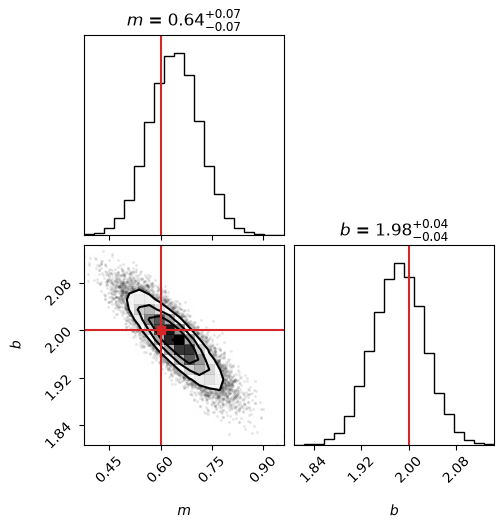

In [8]:
fig = corner.corner(
    samples,
    labels=[f"${p.latex}$" for p in problem.params],
    truths=[truth[n] for n in problem.names],
    truth_color="C3",
    show_titles=True,
)
plt.show()

## The posterior predictive on any grid

Binding the model to a finer, wider grid gives the prediction where there are
no data; the band is the percentile envelope over posterior rows.

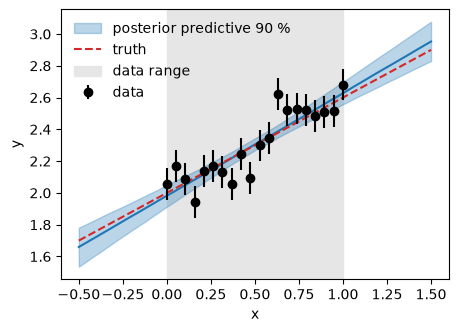

In [9]:
post_curves = np.array(
    [on_fine(*s[problem.columns(line.params)]) for s in samples[::20]]
)
lo, mid, hi = rx.predictive.predictive_band(post_curves, levels=(5, 50, 95))

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.fill_between(
    x_fine, lo, hi, color="C0", alpha=0.3, label="posterior predictive 90 %"
)
ax.plot(x_fine, mid, color="C0")
ax.plot(x_fine, truth["m"] * x_fine + truth["b"], "--", color="C3", label="truth")
ax.errorbar(data.x, data.y, data.y_err, fmt="o", color="k", label="data")
ax.axvspan(x.min(), x.max(), color="0.9", zorder=0, label="data range")
ax.set(xlabel="x", ylabel="y")
ax.legend(frameon=False)
plt.show()

## Is the error model calibrated?

The band above is the model's uncertainty only.  The posterior *predictive*
of the data adds the error model: draws of `ym(θ) + noise` on the data
points.  If the error model is right, a central 68 % interval of those draws
should contain about 68 % of the points, and so on for every level.  Twenty
points make a coarse curve, but it should hug the diagonal.

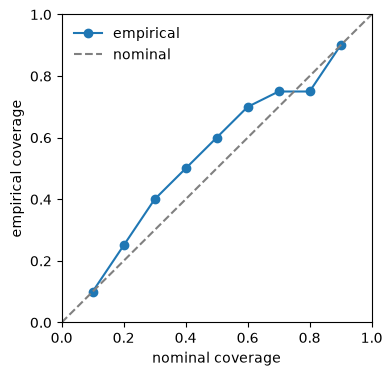

width of the 68 % predictive interval per point: 0.208


In [10]:
draws = rx.diagnostics.predictive_draws(problem, samples[::10], n_rep=4, rng=4)
levels = np.linspace(0.1, 0.9, 9)
c = problem.constraints[0]
coverage = rx.diagnostics.coverage_curve(draws, c.y[c.active], levels)

fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(levels, coverage, "o-", label="empirical")
ax.plot([0, 1], [0, 1], "--", color="0.5", label="nominal")
ax.set(xlabel="nominal coverage", ylabel="empirical coverage", xlim=(0, 1), ylim=(0, 1))
ax.legend(frameon=False)
plt.show()
print(
    f"width of the 68 % predictive interval per point: {rx.diagnostics.sharpness(draws).mean():.3f}"
)

## Takeaways

- Declare, compile, sample: the problem knows its columns, its prior and its
  densities; the sampler is whatever you like.
- Nothing is hidden in the likelihood.  With reported errors only, it is the
  χ² you would write yourself.
- Read chains by name through `problem.columns`; bind the model to any grid
  for predictions.
- The posterior predictive check is the first question to ask of an error
  model.  The next notebooks are about what to do when the reported errors
  are not the whole story.